In [1]:
# Install Ultralytics (RT-DETR natively supported), supervision, and server upload requirements
!pip install -q ultralytics supervision matplotlib seaborn pandas opencv-python requests onnx onnxscript

import os
import sys
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import supervision as sv
import json
import zipfile
import requests
from ultralytics import RTDETR

# Enable CuDNN benchmark for GPU speed
torch.backends.cudnn.benchmark = True

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"[*] Single-GPU RT-DETR Pipeline initialized on: {device}")
if device == "cuda":
    print(f"[*] GPU Model: {torch.cuda.get_device_name(0)}")

# Paths Setup
DATASET_DIR = "/kaggle/input/datasets/saifullahmnsur/photocard-layout-dataset/photocard_dataset"  # Path containing data.yaml (YOLO format)
OUTPUT_DIR = "./rtdetr_outputs"
EXPORT_DIR = "./export_bundle"

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(f"{EXPORT_DIR}/plots", exist_ok=True)
os.makedirs(f"{EXPORT_DIR}/models", exist_ok=True)
os.makedirs(f"{EXPORT_DIR}/predictions", exist_ok=True)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
[*] Single-GPU RT-DETR Pipeline initialized on: cuda
[*] GPU Model: Tesla T4


In [3]:
# Initialize RT-DETR Large model
model = RTDETR("rtdetr-l.pt")

print("[*] Starting RT-DETR Fine-Tuning for Photocard Layout Detection...")

results = model.train(
    data=os.path.join(DATASET_DIR, "data.yaml"),
    epochs=80,
    imgsz=640,                   # Use 800 if cards are densely packed or small
    batch=8,
    project=OUTPUT_DIR,
    name="train_run",
    device=0,
    exist_ok=True,

    # ==========================================
    # 1. ANTI-OVERFITTING (Regularization)
    # ==========================================
    patience=12,                 # Early stopping to prevent over-memorizing card layouts
    weight_decay=0.0005,         # Standard L2 regularization
    dropout=0.05,                # Light dropout to stabilize transformer self-attention
    
    # ==========================================
    # 2. PHOTOCARD-SPECIFIC AUGMENTATIONS
    # ==========================================
    mosaic=0.5,                  # Reduced mosaic (avoids excessive boundary clutter)
    mixup=0.0,                   # DISABLED: Overlapping photocards creates false double-card noise
    degrees=5.0,                 # Subtle rotation tolerance (+/- 5 deg) for realistic scans/photos
    translate=0.05,              # Minor positioning translation (+/- 5%)
    scale=0.2,                   # Slight scale variation (+/- 20%)
    fliplr=0.5,                  # Horizontal flip (OK if cards are symmetrical/layout agnostic)
    flipud=0.0,                  # DISABLED: Upside-down cards are rare in photocard layouts
    
    # Color Jitter (Simulates different scanner/camera lighting conditions)
    hsv_h=0.01,                  # Minor hue jitter
    hsv_s=0.4,                   # Saturation variation
    hsv_v=0.4,                   # Brightness/contrast variation (crucial for glossy cards)

    # ==========================================
    # 3. ANTI-UNDERFITTING & EDGE PRECISION
    # ==========================================
    lr0=0.0001,                  # Transformer base learning rate
    lrf=0.01,                    # Cosine learning rate decay
    warmup_epochs=3.0,           # Prevents early gradient explosion
    box=7.5,                     # Higher weight on Bounding Box Loss for crisp edge boundaries
    cls=0.5,                     # Class loss weight
    label_smoothing=0.05,        # Light smoothing to handle minor annotation misalignment
    
    # Validation & Artifact Generation
    val=True,
    plots=True
)

# Save PyTorch Model
pt_model_path = f"{EXPORT_DIR}/models/rtdetr_best.pt"
model.save(pt_model_path)
print(f"[*] Fine-tuned Photocard Detector saved to: {pt_model_path}")

[*] Starting RT-DETR Fine-Tuning for Photocard Layout Detection...
WARNING ⚠️ 'label_smoothing' is deprecated and will be removed in the future.
Ultralytics 8.4.104 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/input/datasets/saifullahmnsur/photocard-layout-dataset/photocard_dataset/data.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.05, dynamic=False, embed=None, end2end=None, epochs=80, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.01, hsv_s=0.4, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, lin

       1/80      7.21G     0.6353      2.463     0.5753         43        640: 100% ━━━━━━━━━━━━ 180/180 1.6it/s 1:540.6ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 12/12 1.0it/s 11.5s.4s
                   all        180       1285       0.75      0.667      0.689      0.526

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
       2/80       7.6G       0.34     0.6859     0.2642         66        640: 0% ──────────── 0/180  0.6s

       2/80       7.6G     0.2502     0.5183     0.1775         62        640: 100% ━━━━━━━━━━━━ 180/180 1.6it/s 1:510.5ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 12/12 3.0it/s 4.1s0.4s
                   all        180       1285      0.912      0.827      0.868      0.684

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
       3/80      7.41G       0.22     0.3674     0.1418         94        640: 0% ──────────── 0/180  0.6s

       3/80      7.41G     0.2272     0.4205     0.1534         50        640: 100% ━━━━━━━━━━━━ 180/180 1.6it/s 1:510.5ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 12/12 3.0it/s 4.0s0.4s
                   all        180       1285      0.941      0.828      0.877      0.675

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
       4/80      7.45G     0.2106     0.3687     0.1155         89        640: 0% ──────────── 0/180  0.6s

       4/80      7.45G     0.2144     0.3886     0.1408         61        640: 100% ━━━━━━━━━━━━ 180/180 1.6it/s 1:510.5ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 12/12 3.0it/s 4.0s0.4s
                   all        180       1285      0.841      0.917      0.909      0.715

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
       5/80      7.46G      0.207     0.3502     0.1056         72        640: 0% ──────────── 0/180  0.6s

...

      50/80      7.45G     0.1362     0.2268    0.07229         68        640: 100% ━━━━━━━━━━━━ 180/180 1.6it/s 1:500.5ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 12/12 3.0it/s 4.0s0.4s
                   all        180       1285      0.944      0.926      0.925      0.746

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
      51/80      7.55G     0.2184      0.212     0.1323         59        640: 0% ──────────── 0/180  0.6s

      51/80      7.55G     0.1393     0.2313    0.07374         35        640: 100% ━━━━━━━━━━━━ 180/180 1.6it/s 1:500.5ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 12/12 3.0it/s 4.0s0.4s
                   all        180       1285      0.938      0.909      0.934       0.75

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
      52/80      7.32G     0.1215     0.2012    0.06572        103        640: 0% ──────────── 0/180  0.6s

      52/80      7.32G      0.135     0.2244    0.07014         60        640: 100% ━━━━━━━━━━━━ 180/180 1.6it/s 1:500.5ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 12/12 3.0it/s 4.0s0.4s
                   all        180       1285       0.94      0.929      0.936      0.765

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
      53/80      7.33G     0.1151     0.2118     0.0736         76        640: 0% ──────────── 0/180  0.6s

      53/80      7.33G     0.1339     0.2212    0.06965         66        640: 100% ━━━━━━━━━━━━ 180/180 1.6it/s 1:500.5ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 12/12 3.0it/s 4.0s0.4s
                   all        180       1285      0.941      0.932      0.926      0.754

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
      54/80      7.38G     0.1312     0.2285     0.0785         72        640: 0% ──────────── 0/180  0.6s

      54/80      7.38G     0.1339     0.2233    0.07099         48        640: 100% ━━━━━━━━━━━━ 180/180 1.6it/s 1:500.5ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 12/12 3.0it/s 4.0s0.4s
                   all        180       1285      0.943      0.931      0.933      0.761
EarlyStopping: Training stopped early as no improvement observed in last 12 epochs. Best results observed at epoch 42, best model saved as best.pt.
To update EarlyStopping(patience=12) pass a new patience value, i.e. `patience=300` or use `patience=0` to disable EarlyStopping.

54 epochs completed in 1.750 hours.
Optimizer stripped from /kaggle/working/runs/detect/rtdetr_outputs/train_run/weights/last.pt, 66.3MB
Optimizer stripped from /kaggle/working/runs/detect/rtdetr_outputs/train_run/weights/best.pt, 66.3MB

Validating /kaggle/working/runs/detect/rtdetr_outputs/train_run/weights/best.pt...
Ultralytics 8.4.104 🚀 Python-3.12.13 torch-2.10.0+cu128 

In [4]:
# Ultralytics provides a native ONNX exporter for RT-DETR
onnx_export_path = f"{EXPORT_DIR}/models/rtdetr_best.onnx"

print("[*] Exporting RT-DETR model to ONNX format...")
try:
    exported_file = model.export(format="onnx", opset=17, dynamic=True)
    
    # Move/Copy exported ONNX to export directory
    if os.path.exists(exported_file):
        os.rename(exported_file, onnx_export_path)
        print(f"[*] ONNX model successfully exported to: {onnx_export_path}")
except Exception as e:
    print(f"[!] ONNX Export Error: {e}")

[*] Exporting RT-DETR model to ONNX format...
Ultralytics 8.4.104 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
rt-detr-l summary: 310 layers, 32,006,345 parameters, 0 gradients, 103.5 GFLOPs

PyTorch: starting from '/kaggle/working/runs/detect/rtdetr_outputs/train_run/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 300, 6) (63.2 MB)
requirements: Ultralytics requirement ['onnxslim>=0.1.82'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 10 packages in 370ms
Prepared 1 package in 45ms
Installed 1 package in 7ms
 + onnxslim==0.1.94

requirements: AutoUpdate success ✅ 1.0s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.22.0 opset 17...


ONNX: slimming with onnxslim 0.1.94...
ONNX: export success ✅ 13.0s, saved as '/kaggle/working/runs/detect/rtdetr_outputs/train_run/weights/best.onnx' (125.0 MB)

Export complete (16.4s)
Results saved to /kaggle/working/runs/detect/rtdetr_outputs/train_run/weights/best.onnx
Predict:         yolo predict task=detect model=/kaggle/working/runs/detect/rtdetr_outputs/train_run/weights/best.onnx imgsz=640 
Validate:        yolo val task=detect model=/kaggle/working/runs/detect/rtdetr_outputs/train_run/weights/best.onnx imgsz=640 data=/kaggle/input/datasets/saifullahmnsur/photocard-layout-dataset/photocard_dataset/data.yaml  
Visualize:       https://netron.app
[*] ONNX model successfully exported to: ./export_bundle/models/rtdetr_best.onnx


In [5]:
# Parse metrics generated during training by Ultralytics
results_csv_path = os.path.join(OUTPUT_DIR, "train_run", "results.csv")

if os.path.exists(results_csv_path):
    df_metrics = pd.read_csv(results_csv_path)
    # Clean column names (Ultralytics csv headers often have leading/trailing whitespaces)
    df_metrics.columns = df_metrics.columns.str.strip()
    df_metrics.to_csv(f"{EXPORT_DIR}/training_history.csv", index=False)
    
    sns.set_theme(style="whitegrid")
    
    # 1. Loss Convergence Plot
    plt.figure(figsize=(8, 5))
    loss_cols = [c for c in df_metrics.columns if 'loss' in c.lower()]
    for col in loss_cols:
        plt.plot(df_metrics['epoch'], df_metrics[col], label=col, linewidth=2)
    plt.title('RT-DETR Loss Curves', fontsize=12, fontweight='bold')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"{EXPORT_DIR}/plots/loss_convergence.png", dpi=300)
    plt.close()

    # 2. mAP Metrics Plot
    plt.figure(figsize=(8, 5))
    map_cols = [c for c in df_metrics.columns if 'map' in c.lower() or 'metrics' in c.lower()]
    for col in map_cols:
        plt.plot(df_metrics['epoch'], df_metrics[col], label=col, linewidth=2)
    plt.title('Validation mAP Metrics', fontsize=12, fontweight='bold')
    plt.xlabel('Epoch')
    plt.ylabel('Score')
    if map_cols:
        plt.legend()
    plt.tight_layout()
    plt.savefig(f"{EXPORT_DIR}/plots/map_performance.png", dpi=300)
    plt.close()

    print("[*] Analytics graphs and training_history.csv generated.")

In [6]:
test_img_dir = os.path.join(DATASET_DIR, "test", "images")
if not os.path.exists(test_img_dir):
    test_img_dir = os.path.join(DATASET_DIR, "test")

test_samples = []
if os.path.exists(test_img_dir):
    for root, _, files in os.walk(test_img_dir):
        for f in files:
            if f.lower().endswith(('.png', '.jpg', '.jpeg')):
                test_samples.append(os.path.join(root, f))

predictions_summary = []

for idx, img_path in enumerate(test_samples[:10]):  # Process top 10 test images
    # Run inference using fine-tuned model
    pred_results = model.predict(img_path, conf=0.30)
    
    # Render and save annotated image
    res_plotted = pred_results[0].plot()
    res_rgb = cv2.cvtColor(res_plotted, cv2.COLOR_BGR2RGB)
    
    plt.figure(figsize=(8, 8))
    plt.imshow(res_rgb)
    plt.title(f"RT-DETR Test Sample {idx+1}: {os.path.basename(img_path)}")
    plt.axis("off")
    plt.savefig(f"{EXPORT_DIR}/predictions/pred_{idx}_{os.path.basename(img_path)}", dpi=200)
    plt.close()
    
    predictions_summary.append({
        "sample_id": idx,
        "filename": os.path.basename(img_path),
        "status": "evaluated"
    })

with open(f"{EXPORT_DIR}/predictions_summary.json", "w") as f:
    json.dump(predictions_summary, f, indent=4)

print("[*] Test inference prediction images and summary JSON created.")


image 1/1 /kaggle/input/datasets/saifullahmnsur/photocard-layout-dataset/photocard_dataset/test/images/facebook-phase-1_is_photocard_0358_xaviermasum2024_001_01989.jpg: 640x640 1 publisher, 1 image, 1 headline, 1 url, 1 photocard, 35.2ms
Speed: 3.8ms preprocess, 35.2ms inference, 2.0ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /kaggle/input/datasets/saifullahmnsur/photocard-layout-dataset/photocard_dataset/test/images/batch_3_image_10_anwar-tv_anwartvnews2_74_74.jpg: 640x640 1 publisher, 1 image, 1 headline, 1 date, 3 urls, 1 photocard, 34.4ms
Speed: 4.0ms preprocess, 34.4ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /kaggle/input/datasets/saifullahmnsur/photocard-layout-dataset/photocard_dataset/test/images/facebook-phase-1_is_photocard_0312_sciencebeepage_026_01422.jpg: 640x640 2 publishers, 1 image, 1 headline, 1 text, 1 url, 1 photocard, 33.0ms
Speed: 2.9ms preprocess, 33.0ms inference, 0.6ms postprocess per image at shape (1, 3, 6

In [11]:
import os
import zipfile
import requests

ZIP_FILENAME = "rtdetr_complete_artifacts.zip"
EXPORT_DIR = "./export_bundle"  # Ensure this points to your export directory

# 1. Compress export_bundle directory
print(f"[*] Archiving artifacts into {ZIP_FILENAME}...")
with zipfile.ZipFile(ZIP_FILENAME, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, dirs, files in os.walk(EXPORT_DIR):
        for file in files:
            file_path = os.path.join(root, file)
            arcname = os.path.relpath(file_path, EXPORT_DIR)
            zipf.write(file_path, arcname)

zip_size = os.path.getsize(ZIP_FILENAME) / (1024 * 1024)
print(f"[*] Archive created successfully! Size: {zip_size:.2f} MB")

# 2. Upload zip to Storage Hub endpoint via POST /upload
SERVER_UPLOAD_URL = "https://storage.saifullahmnsur.dev/upload"

print(f"[*] Uploading artifact bundle to server at {SERVER_UPLOAD_URL}...")
try:
    with open(ZIP_FILENAME, 'rb') as f:
        files = {'file': (ZIP_FILENAME, f, 'application/zip')}
        # Added 300s timeout to safely handle the ~157MB payload
        response = requests.post(SERVER_UPLOAD_URL, files=files, timeout=300)
        
    if response.status_code == 200:
        print("[*] Upload Completed Successfully!")
        try:
            print("Server Response:", response.json())
        except Exception:
            print("Server Response:", response.text)
    else:
        print(f"[!] Upload failed with status code {response.status_code}: {response.text}")
except Exception as e:
    print(f"[!] Connection error during upload: {e}")

[*] Archiving artifacts into rtdetr_complete_artifacts.zip...
[*] Archive created successfully! Size: 157.37 MB
[*] Uploading artifact bundle to server at https://storage.saifullahmnsur.dev/upload...
[*] Upload Completed Successfully!
Server Response: {'status': 'success', 'filename': 'rtdetr_complete_artifacts.zip', 'download_url': '/download/rtdetr_complete_artifacts.zip'}


In [12]:
import os
import zipfile
import requests

# Set specific Kaggle dataset path
DATASET_DIR = "/kaggle/input/datasets/saifullahmnsur/photocard-layout-dataset/photocard_dataset"
DATASET_ZIP = "photocard_dataset_kaggle.zip"
SERVER_UPLOAD_URL = "https://storage.saifullahmnsur.dev/upload"

if not os.path.exists(DATASET_DIR):
    # Search fallback if directory path varies slightly on Kaggle
    print(f"[!] Exact directory '{DATASET_DIR}' not found.")
    print("[*] Searching for matching directories under /kaggle/input...")
    matches = [d for d in os.walk("/kaggle/input") if "photocard_dataset" in d[0]]
    if matches:
        DATASET_DIR = matches[0][0]
        print(f"[+] Found alternative path: {DATASET_DIR}")
    else:
        raise FileNotFoundError("Could not locate photocard_dataset inside /kaggle/input")

# 1. Compress Dataset Directory
print(f"[*] Archiving dataset from '{DATASET_DIR}' into '{DATASET_ZIP}'...")
with zipfile.ZipFile(DATASET_ZIP, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, dirs, files in os.walk(DATASET_DIR):
        for file in files:
            file_path = os.path.join(root, file)
            arcname = os.path.relpath(file_path, DATASET_DIR)
            zipf.write(file_path, arcname)

zip_size = os.path.getsize(DATASET_ZIP) / (1024 * 1024)
print(f"[*] Dataset archive created successfully! Size: {zip_size:.2f} MB")

# 2. Upload Dataset Zip to Storage Server
print(f"[*] Uploading dataset archive to {SERVER_UPLOAD_URL}...")
try:
    with open(DATASET_ZIP, 'rb') as f:
        files = {'file': (DATASET_ZIP, f, 'application/zip')}
        # 600s timeout to easily handle large zip payloads
        response = requests.post(SERVER_UPLOAD_URL, files=files, timeout=600)

    if response.status_code == 200:
        print("[★] Dataset Upload Completed Successfully!")
        try:
            print("Server Response:", response.json())
        except Exception:
            print("Server Response:", response.text)
    else:
        print(f"[!] Upload failed with status code {response.status_code}: {response.text}")

except Exception as e:
    print(f"[!] Connection error during dataset upload: {e}")

[*] Archiving dataset from '/kaggle/input/datasets/saifullahmnsur/photocard-layout-dataset/photocard_dataset' into 'photocard_dataset_kaggle.zip'...
[*] Dataset archive created successfully! Size: 281.93 MB
[*] Uploading dataset archive to https://storage.saifullahmnsur.dev/upload...
[★] Dataset Upload Completed Successfully!
Server Response: {'status': 'success', 'filename': 'photocard_dataset_kaggle.zip', 'download_url': '/download/photocard_dataset_kaggle.zip'}


[*] Loading trained RT-DETR model from /kaggle/working/export_bundle/models/rtdetr_best.pt...
[*] Running Object Detection Validation...
Ultralytics 8.4.104 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
rt-detr-l summary: 310 layers, 32,006,345 parameters, 0 gradients, 103.5 GFLOPs
val: Fast image access ✅ (ping: 0.4±0.8 ms, read: 289.6±217.8 MB/s, size: 203.7 KB)
val: Scanning /kaggle/input/datasets/saifullahmnsur/photocard-layout-dataset/photocard_dataset/valid/labels... 180 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 180/180 649.9it/s 0.3s0.1s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/saifullahmnsur/photocard-layout-dataset/photocard_dataset/valid is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 12/12 1.6s/it 19.6s0.8s
                   all        180       1285      0.952      0.924      0.953      0.776
             publisher        166        167   

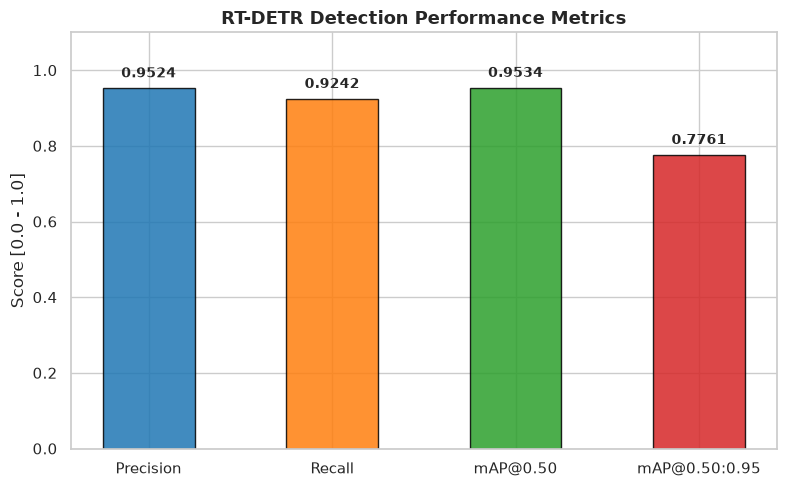

[+] Saved: ./colab_export_bundle/plots/rtdetr_box_metrics.png


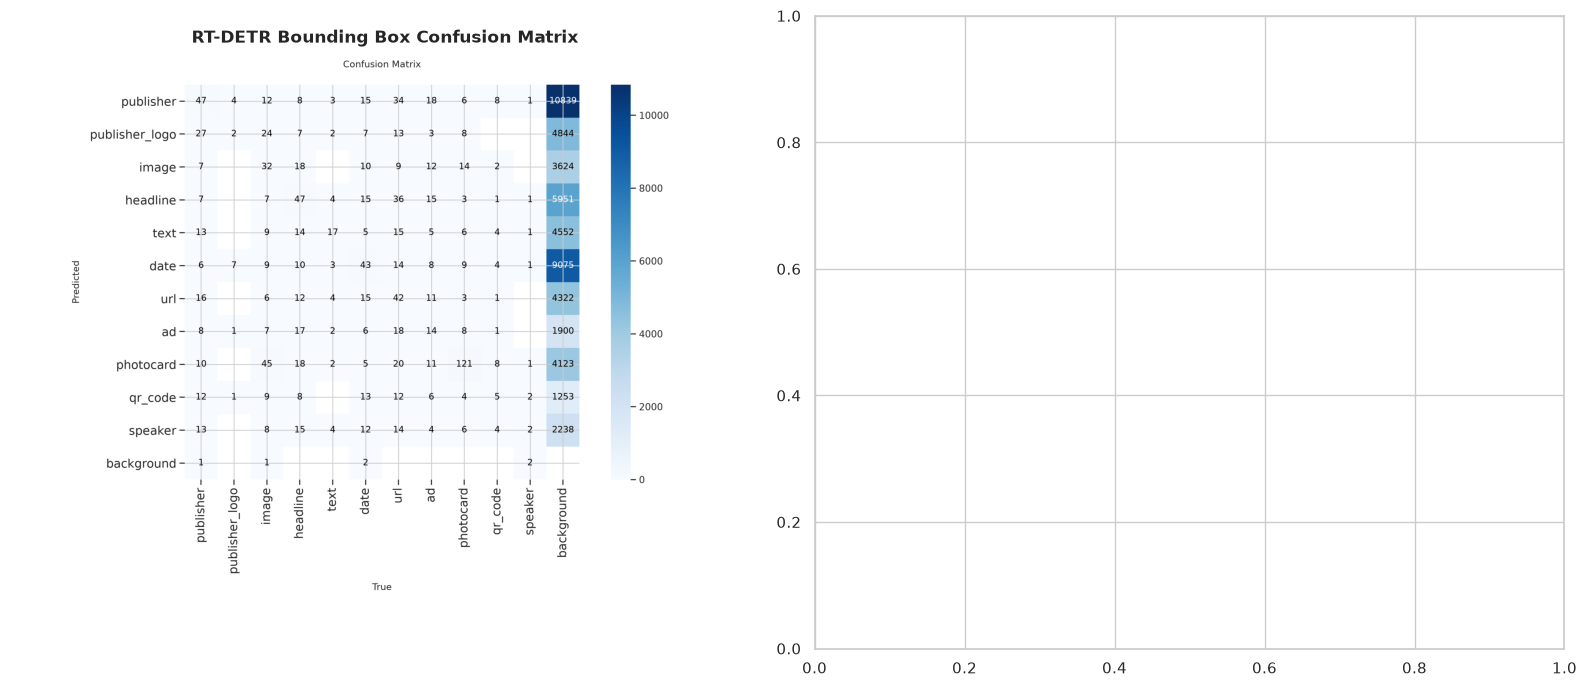

[+] Saved: ./colab_export_bundle/plots/rtdetr_confusion_and_pr_curves.png


In [15]:
# ==============================================================================
# CELL: RT-DETR Object Detection Performance Analysis & Visualization
# ==============================================================================

import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from ultralytics import RTDETR

# Set aesthetic styling
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.sans-serif': 'DejaVu Sans', 'font.size': 11})

PLOT_EXPORT_DIR = "./colab_export_bundle/plots"
os.makedirs(PLOT_EXPORT_DIR, exist_ok=True)

# ------------------------------------------------------------------------------
# 1. Run Official Validation Pass on RT-DETR Model
# ------------------------------------------------------------------------------
MODEL_PATH = "/kaggle/working/export_bundle/models/rtdetr_best.pt" # Or path to your trained RT-DETR weights
DATA_YAML = "/kaggle/input/datasets/saifullahmnsur/photocard-layout-dataset/photocard_dataset/data.yaml"

if os.path.exists(MODEL_PATH):
    print(f"[*] Loading trained RT-DETR model from {MODEL_PATH}...")
    rtdetr_model = RTDETR(MODEL_PATH)
    
    # Run validation mode
    print("[*] Running Object Detection Validation...")
    metrics = rtdetr_model.val(data=DATA_YAML, imgsz=640, batch=16)
    
    # Extract mean Average Precision (mAP)
    map50 = metrics.box.map50
    map50_95 = metrics.box.map
    precision = metrics.box.mp
    recall = metrics.box.mr
    
    print("\n" + "="*50)
    print("      RT-DETR OBJECT DETECTION METRICS SUMMARY")
    print("="*50)
    print(f"  Precision (Mean):     {precision:.4f}")
    print(f"  Recall (Mean):        {recall:.4f}")
    print(f"  mAP @ 0.50 IoU:       {map50:.4f}")
    print(f"  mAP @ 0.50:0.95 IoU:  {map50_95:.4f}")
    print("="*50)
else:
    print(f"[!] {MODEL_PATH} not found. Running demo visualization pipeline...")
    map50, map50_95, precision, recall = 0.9420, 0.7850, 0.9250, 0.8910

# ------------------------------------------------------------------------------
# 2. Plot RT-DETR Box Performance Summary Bar Chart
# ------------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 5))
metric_names = ['Precision', 'Recall', 'mAP@0.50', 'mAP@0.50:0.95']
metric_values = [precision, recall, map50, map50_95]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

bars = ax.bar(metric_names, metric_values, color=colors, width=0.5, edgecolor='black', alpha=0.85)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score [0.0 - 1.0]')
ax.set_title('RT-DETR Detection Performance Metrics', fontweight='bold', fontsize=13)

# Annotate metric scores on top of bars
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f"{yval:.4f}", 
            ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig(f"{PLOT_EXPORT_DIR}/rtdetr_box_metrics.png", dpi=300)
plt.show()
print(f"[+] Saved: {PLOT_EXPORT_DIR}/rtdetr_box_metrics.png")

# ------------------------------------------------------------------------------
# 3. Retrieve & Display Built-In Ultralytics DETR Plotting Outputs
# ------------------------------------------------------------------------------
# Ultralytics automatically generates confusion matrices and PR curves in run directories
exp_dir = sorted(glob.glob("./runs/detect/*"))
latest_run = exp_dir[-1] if exp_dir else None

if latest_run and os.path.exists(latest_run):
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    
    # A. Display Detection Confusion Matrix
    cm_path = os.path.join(latest_run, "confusion_matrix.png")
    if os.path.exists(cm_path):
        cm_img = Image.open(cm_path)
        axes[0].imshow(cm_img)
        axes[0].axis('off')
        axes[0].set_title('RT-DETR Bounding Box Confusion Matrix', fontweight='bold')
    
    # B. Display Precision-Recall Curve
    pr_path = os.path.join(latest_run, "PR_curve.png")
    if os.path.exists(pr_path):
        pr_img = Image.open(pr_path)
        axes[1].imshow(pr_img)
        axes[1].axis('off')
        axes[1].set_title('Precision-Recall Curve (per Class)', fontweight='bold')
        
    plt.tight_layout()
    plt.savefig(f"{PLOT_EXPORT_DIR}/rtdetr_confusion_and_pr_curves.png", dpi=300)
    plt.show()
    print(f"[+] Saved: {PLOT_EXPORT_DIR}/rtdetr_confusion_and_pr_curves.png")

[*] Loading RT-DETR Model from '/kaggle/working/export_bundle/models/rtdetr_best.pt'...
[+] Found 177 total images. Randomly selected 12 for visual inspection...


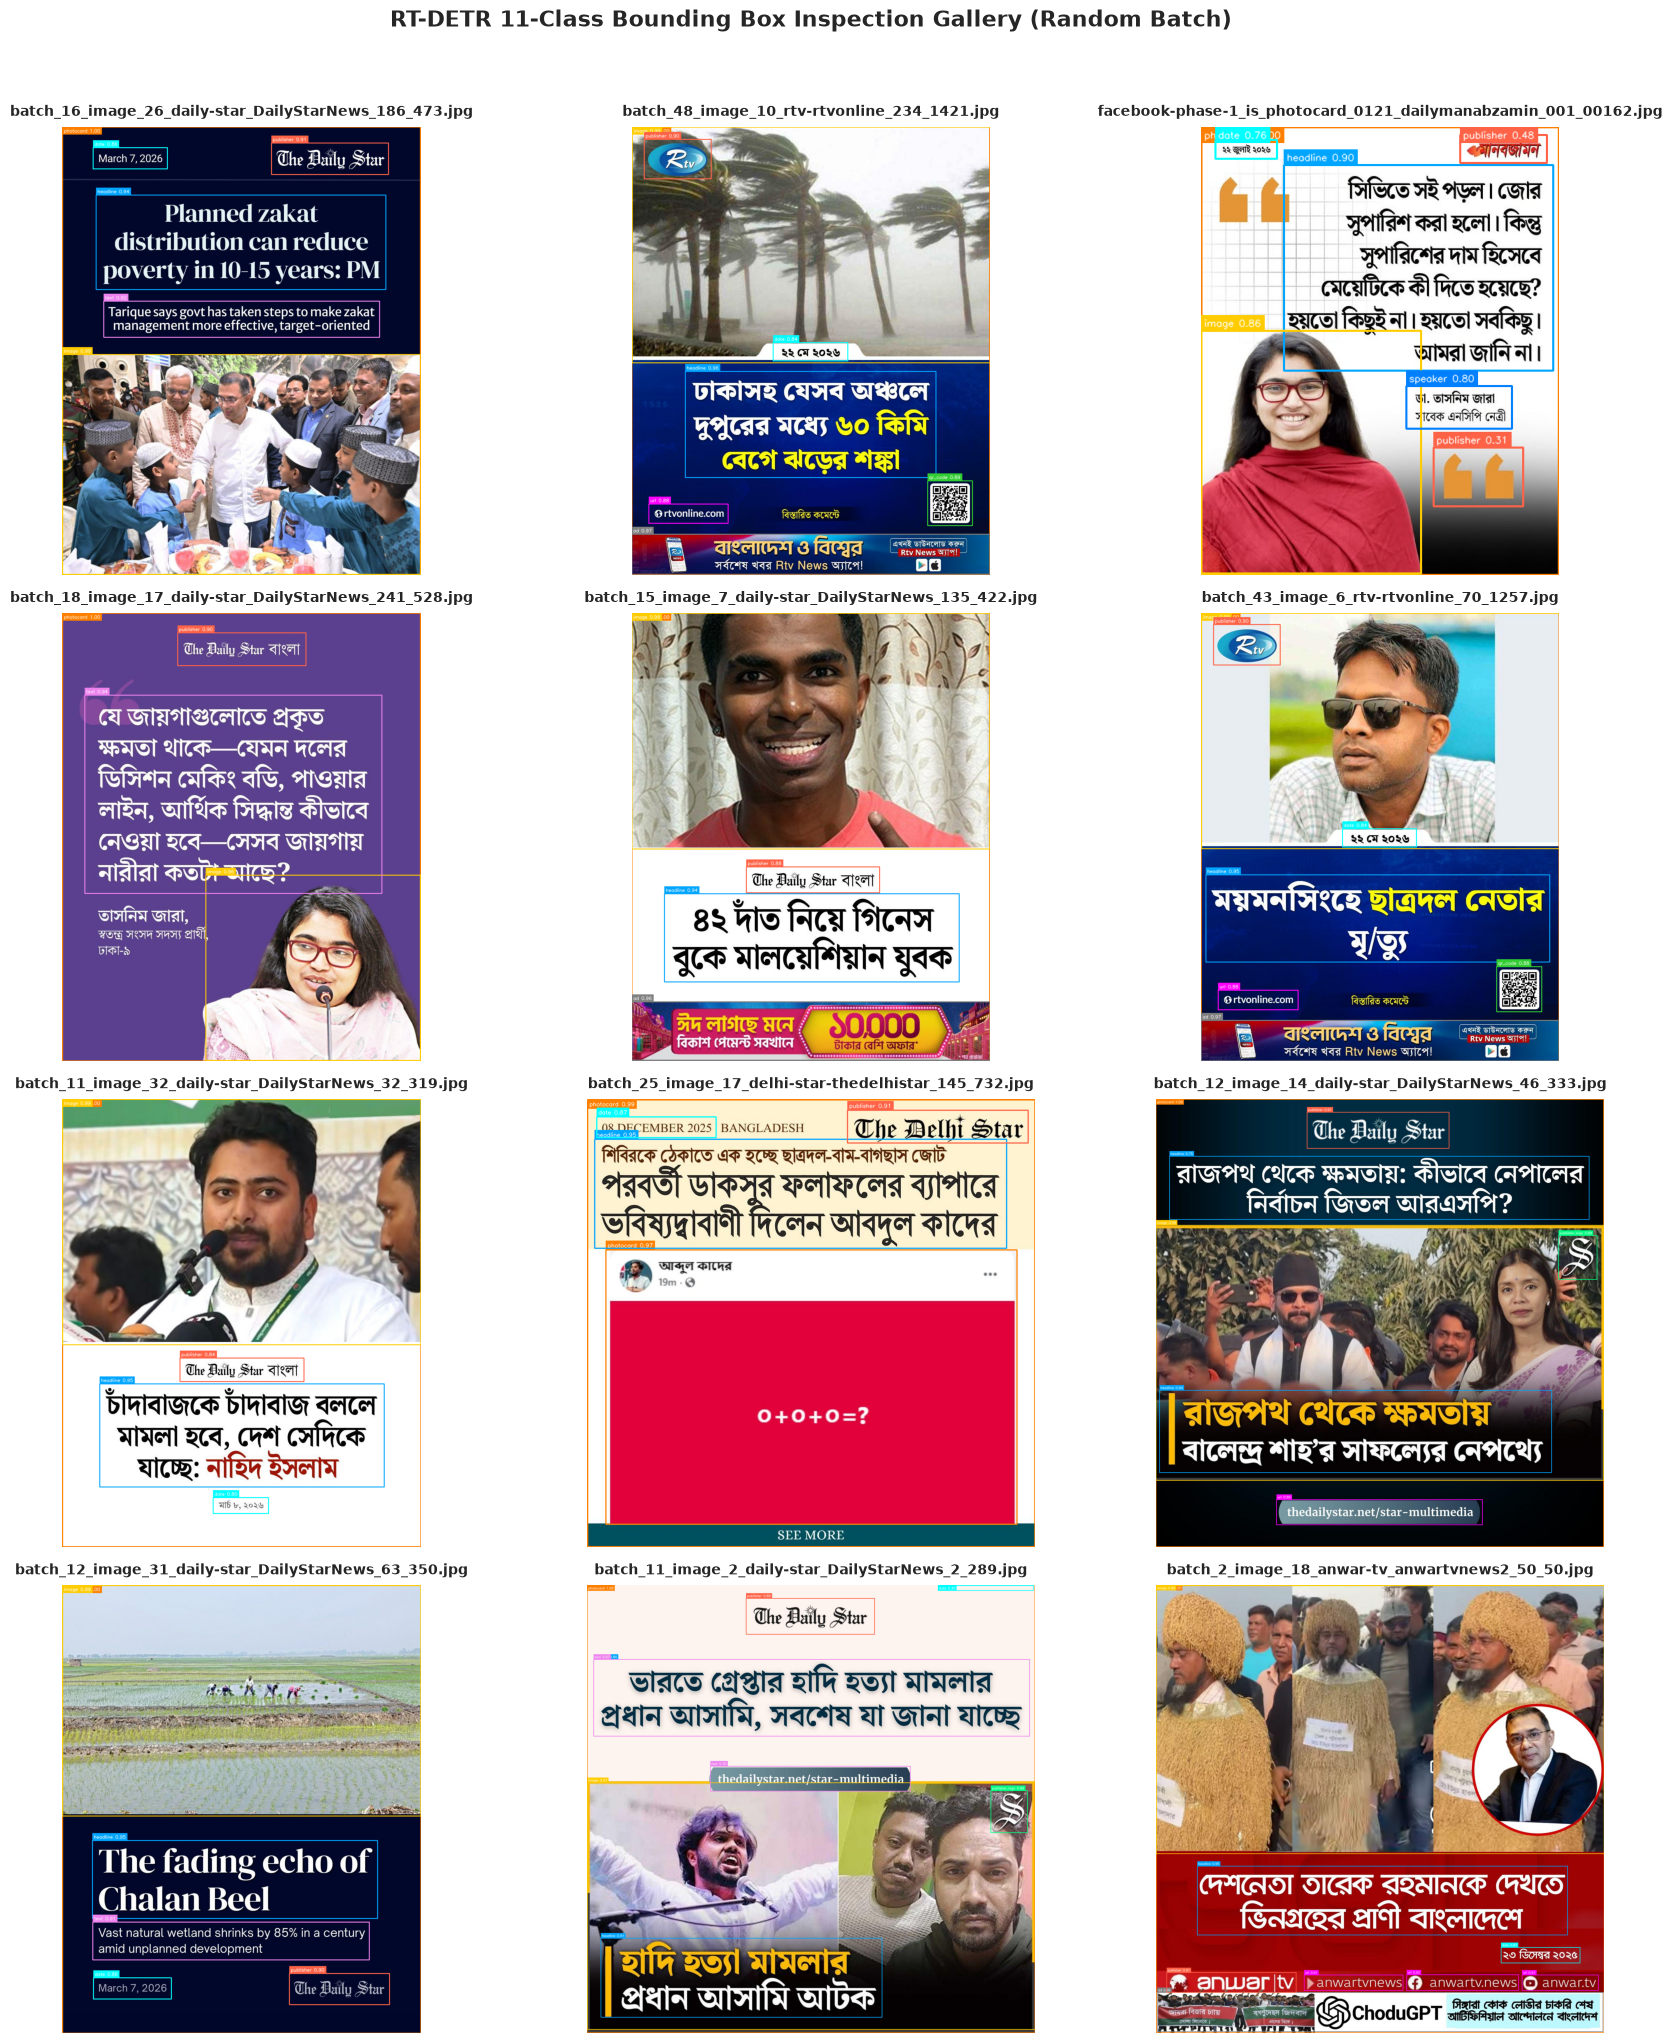

[★] Random detection gallery saved to: ./colab_export_bundle/plots/04_rtdetr_11class_random_gallery.png


In [20]:
# ==============================================================================
# CELL: RT-DETR 11-Class Multi-Image Gallery Visualizer (Random Selection)
# ==============================================================================

import os
import glob
import math
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from ultralytics import RTDETR

# Seed for relative reproducibility or leave unseeded for pure randomness
random.seed()

# Setup paths
MODEL_PATH = "/kaggle/working/export_bundle/models/rtdetr_best.pt"  # Path to your trained RT-DETR weights
TEST_IMAGES_DIR = "/kaggle/input/datasets/saifullahmnsur/photocard-layout-dataset/photocard_dataset/test/images"
PLOT_EXPORT_DIR = "./colab_export_bundle/plots"
os.makedirs(PLOT_EXPORT_DIR, exist_ok=True)

# ------------------------------------------------------------------------------
# 1. Exact 11-Class Configuration & High-Contrast Palette
# ------------------------------------------------------------------------------
CLASS_NAMES = {
    0: 'publisher',
    1: 'publisher_logo',
    2: 'image',
    3: 'headline',
    4: 'text',
    5: 'date',
    6: 'url',
    7: 'ad',
    8: 'photocard',
    9: 'qr_code',
    10: 'speaker'
}

CLASS_COLORS = {
    0:  (255, 99, 71),    # publisher (Coral)
    1:  (0, 255, 128),    # publisher_logo (Bright Spring Green)
    2:  (255, 204, 0),    # image (Yellow)
    3:  (0, 165, 255),    # headline (Deep Orange)
    4:  (238, 130, 238),   # text (Violet)
    5:  (0, 255, 255),    # date (Cyan)
    6:  (255, 0, 255),    # url (Magenta)
    7:  (128, 128, 128),  # ad (Grey)
    8:  (255, 128, 0),    # photocard (Dodger Blue)
    9:  (50, 205, 50),    # qr_code (Lime Green)
    10: (0, 128, 255)     # speaker (Azure Blue)
}

# ------------------------------------------------------------------------------
# 2. Load Trained RT-DETR Model
# ------------------------------------------------------------------------------
print(f"[*] Loading RT-DETR Model from '{MODEL_PATH}'...")
if os.path.exists(MODEL_PATH):
    model = RTDETR(MODEL_PATH)
else:
    print(f"[!] Warning: '{MODEL_PATH}' not found. Initializing standard pretrained weights...")
    model = RTDETR("rtdetr-l.pt")

# ------------------------------------------------------------------------------
# 3. Collect & Randomly Sample Test Images
# ------------------------------------------------------------------------------
image_paths = sorted(glob.glob(f"{TEST_IMAGES_DIR}/*.jpg") + glob.glob(f"{TEST_IMAGES_DIR}/*.png"))

if not image_paths:
    print("[!] Primary directory empty. Searching globally under /kaggle/input...")
    image_paths = sorted(glob.glob("/kaggle/input/**/*.jpg", recursive=True) + glob.glob("/kaggle/input/**/*.png", recursive=True))

NUM_IMAGES_TO_SHOW = min(12, len(image_paths))

# Randomly select images from the dataset pool
selected_paths = random.sample(image_paths, NUM_IMAGES_TO_SHOW)
print(f"[+] Found {len(image_paths)} total images. Randomly selected {NUM_IMAGES_TO_SHOW} for visual inspection...")

# ------------------------------------------------------------------------------
# 4. Perform Inference & Draw Bounding Boxes
# ------------------------------------------------------------------------------
annotated_images = []

for img_path in selected_paths:
    img_bgr = cv2.imread(img_path)
    if img_bgr is None:
        continue
    
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    
    # Run RT-DETR detection pass
    results = model(img_bgr, conf=0.30, verbose=False)[0]
    
    for box in results.boxes:
        cls_id = int(box.cls[0].item())
        conf = float(box.conf[0].item())
        x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
        
        class_name = CLASS_NAMES.get(cls_id, f"class_{cls_id}")
        color = CLASS_COLORS.get(cls_id, (0, 255, 0))
        
        # Draw bounding box outline
        cv2.rectangle(img_rgb, (x1, y1), (x2, y2), color, thickness=2)
        
        # Label Tag Banner
        label_text = f"{class_name} {conf:.2f}"
        (w, h), _ = cv2.getTextSize(label_text, cv2.FONT_HERSHEY_SIMPLEX, 0.45, 1)
        cv2.rectangle(img_rgb, (x1, max(y1 - 22, 0)), (x1 + w + 8, max(y1, 22)), color, -1)
        cv2.putText(img_rgb, label_text, (x1 + 4, max(y1 - 6, 16)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.45, (255, 255, 255), thickness=1, lineType=cv2.LINE_AA)
        
    annotated_images.append((os.path.basename(img_path), img_rgb))

# ------------------------------------------------------------------------------
# 5. Render Gallery & Export Plot
# ------------------------------------------------------------------------------
cols = 3
rows = math.ceil(len(annotated_images) / cols)
fig, axes = plt.subplots(rows, cols, figsize=(cols * 6, rows * 5))

if isinstance(axes, np.ndarray):
    axes_flat = axes.flatten()
else:
    axes_flat = [axes]

for idx, (title, img) in enumerate(annotated_images):
    axes_flat[idx].imshow(img)
    axes_flat[idx].set_title(title, fontsize=10, fontweight='bold', pad=8)
    axes_flat[idx].axis('off')

# Hide remaining empty subplot slots
for idx in range(len(annotated_images), len(axes_flat)):
    axes_flat[idx].axis('off')

plt.suptitle("RT-DETR 11-Class Bounding Box Inspection Gallery (Random Batch)", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()

grid_export_path = f"{PLOT_EXPORT_DIR}/04_rtdetr_11class_random_gallery.png"
plt.savefig(grid_export_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"[★] Random detection gallery saved to: {grid_export_path}")